In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.sparse import rand as sprand
import matplotlib.pyplot as plt

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [2]:
# Fake ratings data
n_users = 1000
n_items = 1000
density = 0.01

ratings = sprand(n_users, n_items, density=density, format="csr")
ratings.data = np.random.randint(1, 6, size=ratings.nnz).astype(np.float64)
ratings = ratings.toarray()

rows, cols = ratings.nonzero()
p = np.random.permutation(len(rows))
rows, cols = rows[p], cols[p]


In [3]:
class MatrixFactorization(nn.Module):
    def __init__(self, n_users, n_items, n_factors=20):
        super().__init__()
        self.user_factors = nn.Embedding(n_users, n_factors, sparse=True)
        self.item_factors = nn.Embedding(n_items, n_factors, sparse=True)

    def forward(self, user, item):
        return (self.user_factors(user) * self.item_factors(item)).sum(1)


In [4]:
model = MatrixFactorization(n_users, n_items, n_factors=20).to(device)
loss_func = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=1e-2)


In [5]:
losses = []

for i, (row, col) in enumerate(zip(rows, cols)):
    user = torch.LongTensor([row]).to(device)
    item = torch.LongTensor([col]).to(device)
    rating = torch.FloatTensor([ratings[row, col]]).to(device)

    optimizer.zero_grad()
    prediction = model(user, item)
    loss = loss_func(prediction, rating)
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if i % 10000 == 0:
        print(f"[{i}/{len(rows)}] Loss: {loss.item():.4f}")


[0/10000] Loss: 44.0602


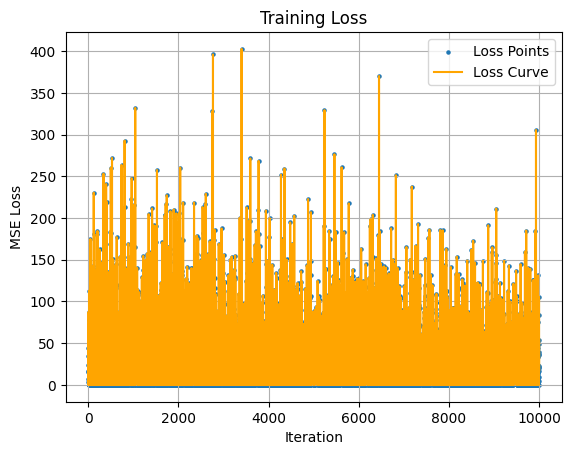

In [6]:
x = list(range(len(losses)))
plt.scatter(x, losses, s=5, label="Loss Points")
plt.plot(x, losses, color="orange", label="Loss Curve")
plt.title("Training Loss")
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.legend()
plt.show()


In [7]:
user_id = 42
item_id = 123

user_tensor = torch.LongTensor([user_id]).to(device)
item_tensor = torch.LongTensor([item_id]).to(device)

pred_rating = model(user_tensor, item_tensor).item()
print(f"Predicted rating by user {user_id} for item {item_id}: {pred_rating:.2f}")


Predicted rating by user 42 for item 123: 4.32


In [8]:
user_tensor = torch.LongTensor([user_id] * n_items).to(device)
item_tensor = torch.LongTensor(range(n_items)).to(device)

with torch.no_grad():
    predictions = model(user_tensor, item_tensor).cpu().numpy()

rated_items = ratings[user_id].nonzero()[0]
predictions[rated_items] = -1  # Ignore already-rated items

top_items = predictions.argsort()[-5:][::-1]
print(f"Top-5 recommendations for user {user_id}: {top_items}")
print(f"Predicted ratings: {predictions[top_items]}")


Top-5 recommendations for user 42: [851 183 850 512 164]
Predicted ratings: [15.275631 14.40267  12.722446 12.144189 11.16333 ]


In [9]:
class BiasedMatrixFactorization(nn.Module):
    def __init__(self, n_users, n_items, n_factors=20):
        super().__init__()
        self.user_factors = nn.Embedding(n_users, n_factors, sparse=True)
        self.item_factors = nn.Embedding(n_items, n_factors, sparse=True)
        self.user_biases = nn.Embedding(n_users, 1, sparse=True)
        self.item_biases = nn.Embedding(n_items, 1, sparse=True)

    def forward(self, user, item):
        pred = self.user_biases(user) + self.item_biases(item)
        pred += (self.user_factors(user) * self.item_factors(item)).sum(dim=1, keepdim=True)
        return pred.squeeze()


In [10]:
model = BiasedMatrixFactorization(n_users, n_items, n_factors=20).to(device)
loss_func = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=1e-2)


In [11]:
losses = []

for i, (row, col) in enumerate(zip(rows, cols)):
    user = torch.LongTensor([row]).to(device)
    item = torch.LongTensor([col]).to(device)
    rating = torch.FloatTensor([ratings[row, col]]).to(device)

    optimizer.zero_grad()
    prediction = model(user, item)
    loss = loss_func(prediction, rating)
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if i % 10000 == 0:
        print(f"[{i}/{len(rows)}] Loss: {loss.item():.4f}")


C:\Users\sthaa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\loss.py:610: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


[0/10000] Loss: 30.7974


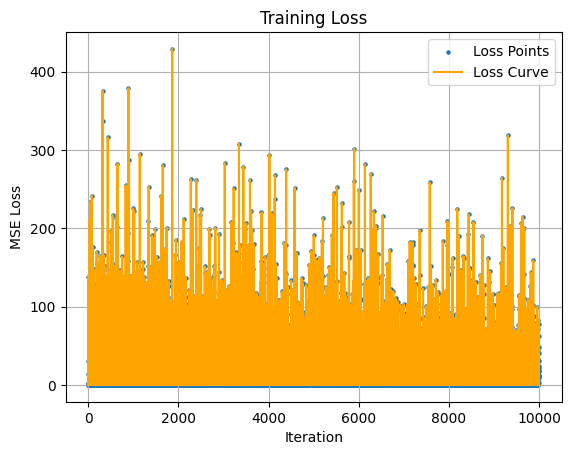

In [12]:
x = list(range(len(losses)))
plt.scatter(x, losses, s=5, label="Loss Points")
plt.plot(x, losses, color="orange", label="Loss Curve")
plt.title("Training Loss")
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.legend()
plt.show()


In [13]:
user_id = 42
item_id = 123

user_tensor = torch.LongTensor([user_id]).to(device)
item_tensor = torch.LongTensor([item_id]).to(device)

pred_rating = model(user_tensor, item_tensor).item()
print(f"Predicted rating by user {user_id} for item {item_id}: {pred_rating:.2f}")


Predicted rating by user 42 for item 123: 2.60


In [14]:
user_tensor = torch.LongTensor([user_id] * n_items).to(device)
item_tensor = torch.LongTensor(range(n_items)).to(device)

with torch.no_grad():
    predictions = model(user_tensor, item_tensor).cpu().numpy()

rated_items = ratings[user_id].nonzero()[0]
predictions[rated_items] = -1  # Ignore already-rated items

top_items = predictions.argsort()[-5:][::-1]
print(f"Top-5 recommended items for user {user_id}: {top_items}")
print(f"Predicted ratings: {predictions[top_items]}")


Top-5 recommended items for user 42: [473 321 762  85 513]
Predicted ratings: [10.235511  10.1932955  8.737126   8.331416   8.140393 ]
